# Student Performance Prediction Using Multiple Linear Regression

### Project Objective

The objective of this project is to analyze student-related factors and predict
their examination scores using Multiple Linear Regression.

### Dataset

- Number of Students: 100
- Number of Variables: 20
- Target Variable: Exam_Score
- Programming Language: Python
- Environment: Jupyter Notebook
- Dataset Source: Student Performance Factors

### Methodology

1. Data Loading
2. Data Inspection
3. Data Cleaning
4. Exploratory Data Analysis
5. Correlation Analysis
6. Multiple Linear Regression
7. Model Assumption Checking
8. Model Refinement
9. Model Evaluation
10. Prediction for a New Student


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
data = pd.read_csv("data/StudentPerformance_100_Clean.csv")

print("Dataset shape:", data.shape)

Dataset shape: (100, 20)


In [3]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,19,96,Medium,Low,Yes,5,86,Medium,No,3,Medium,Medium,Public,Positive,3,No,High School,Moderate,Male,69
1,19,92,High,Medium,Yes,6,52,Medium,Yes,3,High,Medium,Public,Positive,1,No,High School,Near,Male,70
2,15,73,Medium,High,No,7,63,Medium,Yes,2,Medium,Medium,Public,Neutral,5,No,Postgraduate,Moderate,Male,65
3,12,69,High,Medium,Yes,7,92,Low,Yes,1,Medium,Medium,Public,Neutral,3,No,College,Near,Female,64
4,21,91,Medium,High,Yes,9,92,Medium,Yes,5,Low,Medium,Private,Negative,2,No,High School,Near,Male,72


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               100 non-null    int64 
 1   Attendance                  100 non-null    int64 
 2   Parental_Involvement        100 non-null    object
 3   Access_to_Resources         100 non-null    object
 4   Extracurricular_Activities  100 non-null    object
 5   Sleep_Hours                 100 non-null    int64 
 6   Previous_Scores             100 non-null    int64 
 7   Motivation_Level            100 non-null    object
 8   Internet_Access             100 non-null    object
 9   Tutoring_Sessions           100 non-null    int64 
 10  Family_Income               100 non-null    object
 11  Teacher_Quality             100 non-null    object
 12  School_Type                 100 non-null    object
 13  Peer_Influence              100 non-null    object


In [5]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,19.810000,81.160000,7.170000,74.040000,1.460000,2.840000,67.720000
std,6.322471,10.944968,1.477474,14.837109,1.140795,1.041755,4.830626
min,4.000000,61.000000,4.000000,51.000000,0.000000,0.000000,61.000000
25%,16.000000,72.750000,6.000000,61.000000,1.000000,2.000000,65.000000
50%,19.000000,81.500000,7.000000,71.500000,1.000000,3.000000,68.000000
75%,23.000000,91.000000,8.000000,87.250000,2.000000,3.000000,69.000000
max,43.000000,100.000000,10.000000,99.000000,5.000000,5.000000,97.000000


In [6]:
data.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      3
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [7]:
mode_value = data["Parental_Education_Level"].mode()[0]

data["Parental_Education_Level"] = data["Parental_Education_Level"].fillna(mode_value)

print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [8]:
print("Final number of students:", len(data))
print("Final number of variables:", len(data.columns))
print("Dataset shape:", data.shape)

Final number of students: 100
Final number of variables: 20
Dataset shape: (100, 20)


In [9]:
duplicates = data.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [10]:
data.to_csv("data/StudentPerformance_100_Clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## Exploratory Data Analysis

The following analysis explores the distribution of examination scores and
the relationship between important student factors and Exam Score.

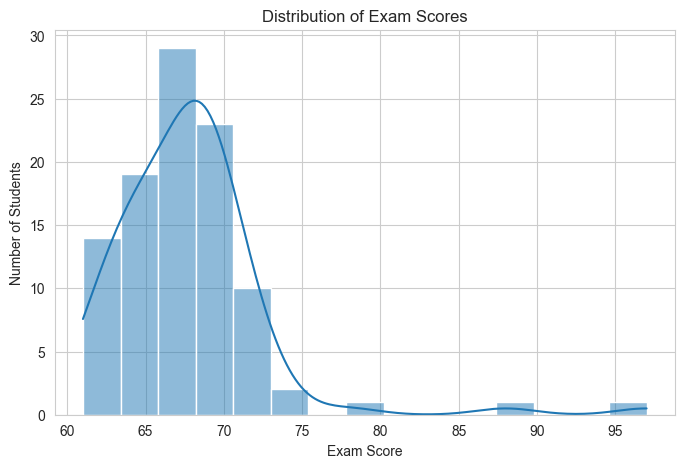

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(data["Exam_Score"], bins=15, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

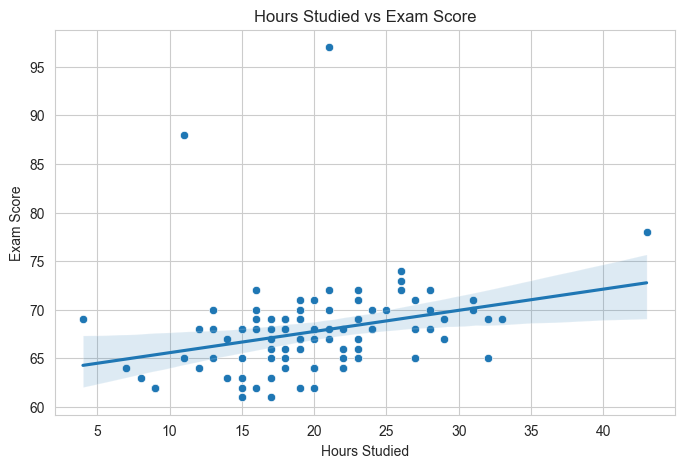

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Hours_Studied",
    y="Exam_Score"
)

sns.regplot(
    data=data,
    x="Hours_Studied",
    y="Exam_Score",
    scatter=False
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

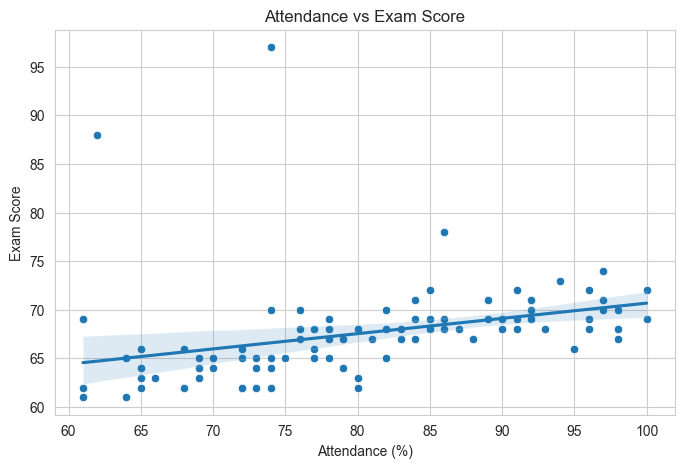

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Attendance",
    y="Exam_Score"
)

sns.regplot(
    data=data,
    x="Attendance",
    y="Exam_Score",
    scatter=False
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

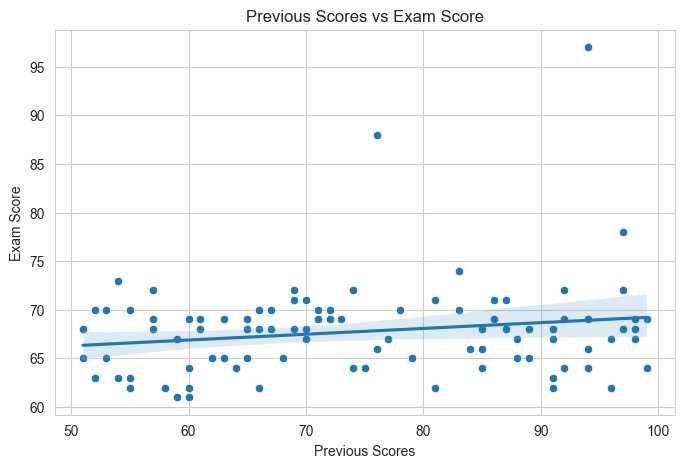

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Previous_Scores",
    y="Exam_Score"
)

sns.regplot(
    data=data,
    x="Previous_Scores",
    y="Exam_Score",
    scatter=False
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")

plt.show()

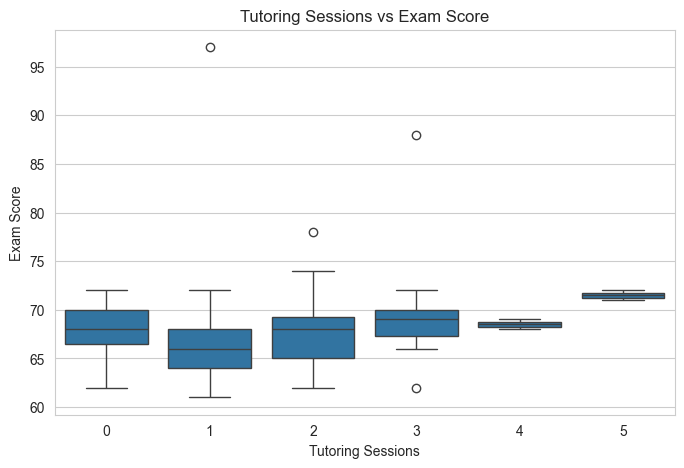

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Tutoring_Sessions",
    y="Exam_Score"
)

plt.title("Tutoring Sessions vs Exam Score")
plt.xlabel("Tutoring Sessions")
plt.ylabel("Exam Score")

plt.show()

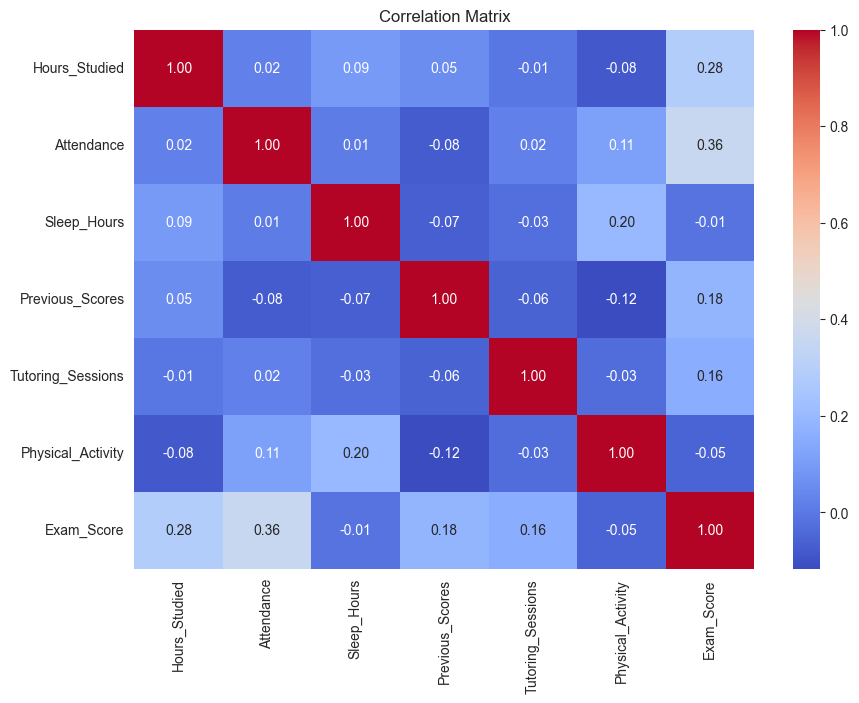

In [16]:
numeric_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

correlation_matrix = data[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [17]:
exam_correlations = correlation_matrix["Exam_Score"].sort_values(
    ascending=False
)

print(exam_correlations)

Exam_Score           1.000000
Attendance           0.355636
Hours_Studied        0.284984
Previous_Scores      0.183370
Tutoring_Sessions    0.157415
Sleep_Hours         -0.013077
Physical_Activity   -0.051144
Name: Exam_Score, dtype: float64


In [18]:
predictors = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

X = data[predictors]
y = data["Exam_Score"]

print("Predictors:")
print(predictors)

print("\nTarget variable:")
print("Exam_Score")

Predictors:
['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Target variable:
Exam_Score


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 80
Testing observations: 20


In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


In [21]:
coefficients = pd.DataFrame({
    "Predictor": predictors,
    "Coefficient": model.coef_
})

coefficients

,Predictor,Coefficient
0,Hours_Studied,0.270191
1,Attendance,0.207541
2,Previous_Scores,0.075245
3,Tutoring_Sessions,0.309672
4,Physical_Activity,-0.437198


In [22]:
print("Intercept:", model.intercept_)

Intercept: 40.658704213963496


In [23]:
equation = f"Exam_Score = {model.intercept_:.4f}"

for predictor, coefficient in zip(predictors, model.coef_):
    equation += f" + ({coefficient:.4f} × {predictor})"

print(equation)

Exam_Score = 40.6587 + (0.2702 × Hours_Studied) + (0.2075 × Attendance) + (0.0752 × Previous_Scores) + (0.3097 × Tutoring_Sessions) + (-0.4372 × Physical_Activity)


In [24]:
train_predictions = model.predict(X_train)

train_r2 = r2_score(y_train, train_predictions)

print("Training R²:", round(train_r2, 4))

Training R²: 0.4149


In [25]:
test_predictions = model.predict(X_test)

print("Test predictions:")
print(test_predictions)

Test predictions:
[61.6479722  71.69451269 69.53217267 69.80831038 68.10138317 71.80477757
 65.54698158 70.47631211 67.9122725  72.81546432 63.51841154 69.21107748
 69.31173771 64.3440418  61.83439535 71.47526876 70.36084419 69.53288482
 71.0319481  63.7242128 ]


In [26]:
mae = mean_absolute_error(y_test, test_predictions)

mse = mean_squared_error(y_test, test_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, test_predictions)

print("Model Evaluation")
print("----------------")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Model Evaluation
----------------
MAE : 2.7163
MSE : 37.3027
RMSE: 6.1076
R²  : -0.3209


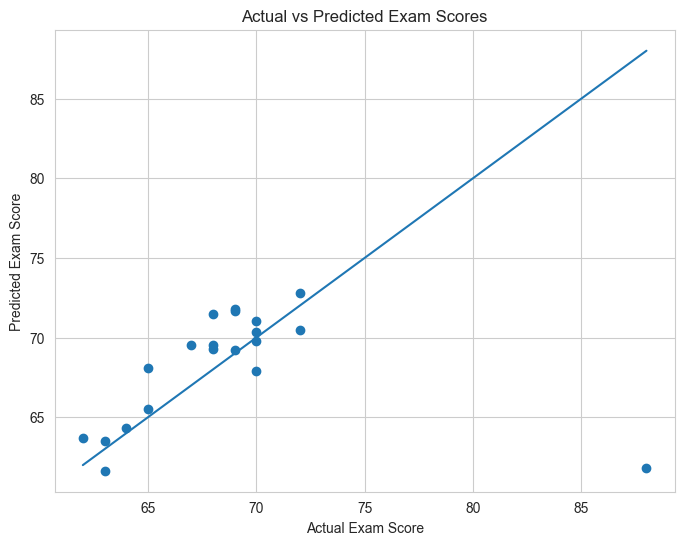

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, test_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

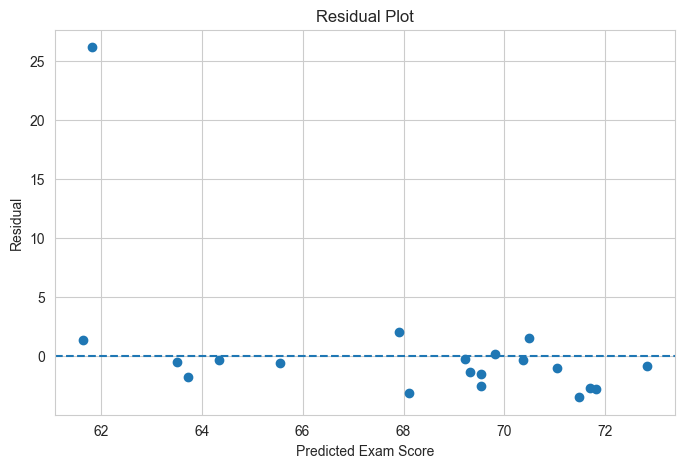

In [28]:
residuals = y_test - test_predictions

plt.figure(figsize=(8, 5))

plt.scatter(test_predictions, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [29]:
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()

vif_data["Variable"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Variable,VIF
0,const,1.000000
1,Hours_Studied,1.010379
2,Attendance,1.018655
3,Previous_Scores,1.023610
4,Tutoring_Sessions,1.005040
5,Physical_Activity,1.033698


In [30]:
X_stats = sm.add_constant(X)

stats_model = sm.OLS(y, X_stats).fit()

print(stats_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     6.966
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.42e-05
Time:                        16:51:13   Log-Likelihood:                -283.13
No. Observations:                 100   AIC:                             578.3
Df Residuals:                      94   BIC:                             593.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                45.2731      4.34

In [31]:
significance = pd.DataFrame({
    "Predictor": stats_model.params.index,
    "Coefficient": stats_model.params.values,
    "P_Value": stats_model.pvalues.values
})

significance

,Predictor,Coefficient,P_Value
0,const,45.273075,2.337947e-17
1,Hours_Studied,0.201821,3.638951e-03
2,Attendance,0.161963,7.948655e-05
3,Previous_Scores,0.065548,2.621828e-02
4,Tutoring_Sessions,0.686089,6.975488e-02
5,Physical_Activity,-0.193999,6.415398e-01


In [32]:
refined_predictors = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores"
]

X_refined = data[refined_predictors]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_refined,
    y,
    test_size=0.20,
    random_state=123
)

refined_model = LinearRegression()

refined_model.fit(X_train_r, y_train_r)

refined_predictions = refined_model.predict(X_test_r)

print("Refined model trained successfully.")

Refined model trained successfully.


In [33]:
refined_mae = mean_absolute_error(
    y_test_r,
    refined_predictions
)

refined_mse = mean_squared_error(
    y_test_r,
    refined_predictions
)

refined_rmse = np.sqrt(refined_mse)

refined_r2 = r2_score(
    y_test_r,
    refined_predictions
)

print("Refined Model Evaluation")
print("------------------------")
print("MAE :", round(refined_mae, 4))
print("MSE :", round(refined_mse, 4))
print("RMSE:", round(refined_rmse, 4))
print("R²  :", round(refined_r2, 4))

Refined Model Evaluation
------------------------
MAE : 2.6404
MSE : 38.2442
RMSE: 6.1842
R²  : -0.3543


In [34]:
final_coefficients = pd.DataFrame({
    "Predictor": refined_predictors,
    "Coefficient": refined_model.coef_
})

final_coefficients

,Predictor,Coefficient
0,Hours_Studied,0.281971
1,Attendance,0.202819
2,Previous_Scores,0.075541


In [35]:
new_student = pd.DataFrame({
    "Hours_Studied": [25],
    "Attendance": [90],
    "Previous_Scores": [80]
})

predicted_score = refined_model.predict(new_student)[0]

print("Predicted Exam Score:", round(predicted_score, 2))

Predicted Exam Score: 71.28


In [36]:
X_final_stats = sm.add_constant(
    data[refined_predictors]
)

final_stats_model = sm.OLS(
    y,
    X_final_stats
).fit()

new_student_stats = sm.add_constant(
    new_student,
    has_constant="add"
)

prediction = final_stats_model.get_prediction(
    new_student_stats
)

prediction_summary = prediction.summary_frame(
    alpha=0.05
)

prediction_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,70.584168,0.674075,69.24614,71.922196,62.001289,79.167047


In [37]:
predicted = prediction_summary["mean"].iloc[0]
lower = prediction_summary["obs_ci_lower"].iloc[0]
upper = prediction_summary["obs_ci_upper"].iloc[0]

print("New Student Prediction")
print("----------------------")
print(f"Predicted Exam Score : {predicted:.2f}")
print(f"95% Prediction Range : {lower:.2f} - {upper:.2f}")

New Student Prediction
----------------------
Predicted Exam Score : 70.58
95% Prediction Range : 62.00 - 79.17


In [38]:
final_results = pd.DataFrame({
    "Metric": [
        "Number of Students",
        "Number of Variables",
        "Training R²",
        "Test R²",
        "MAE",
        "MSE",
        "RMSE"
    ],
    "Value": [
        len(data),
        len(data.columns),
        train_r2,
        r2,
        mae,
        mse,
        rmse
    ]
})

final_results

,Metric,Value
0,Number of Students,100.000000
1,Number of Variables,20.000000
2,Training R²,0.414946
3,Test R²,-0.320916
4,MAE,2.716323
5,MSE,37.302662
6,RMSE,6.107590


## Conclusion

The project uses Multiple Linear Regression to predict student examination
performance from academic and behavioral factors.

The dataset contains 100 students and 20 variables. Missing values were
handled while retaining all 100 student records.

Exploratory analysis was performed to understand relationships between
student factors and examination scores.

Multiple Linear Regression was then trained using selected predictors such
as Hours Studied, Attendance, Previous Scores, Tutoring Sessions, and
Physical Activity.

The model was evaluated using R², MAE, MSE, and RMSE. A separate testing
dataset was used to evaluate prediction performance on unseen observations.

Finally, the model was used to predict the examination score of a
hypothetical student.

The results demonstrate how multiple student-related variables can be used
to build a statistical model for predicting examination performance.